# Load dữ liệu

In [1]:
import pandas as pd

path = "./final-round.json"

# Cách 1: nếu file là 1 mảng JSON: [ {obj1}, {obj2}, ... ]
try:
    df = pd.read_json(path)
    print("Đọc JSON dạng array OK")
except ValueError:
    # Cách 2: nếu file là JSON Lines: mỗi dòng một object
    df = pd.read_json(path, lines=True)
    print("Đọc JSON dạng lines OK")

df.head()

Đọc JSON dạng array OK


,review,sentiment
0,Từ học bổng thay đổi cuộc đời đến lớp học tiến...,positive
1,Trường ĐH Tôn Đức Thắng công bố 4 nhóm nghiên ...,positive
2,Đề thi thử tốt nghiệp THPT môn Toán của thành ...,neutral
3,Sở Giáo dục TPHCM lên tiếng việc 47.000 giáo v...,neutral
4,Người mẹ trăn trở trước giờ ghi 'đơn xanh' ngu...,negative


# Kiểm tra cấu trúc tổng quan

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2444 entries, 0 to 2443
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     2444 non-null   object
 1   sentiment  2444 non-null   object
dtypes: object(2)
memory usage: 38.3+ KB


In [6]:
df.sample(5, random_state=0)


,review,sentiment
1114,"Tổng Bí thư dự gặp mặt đại biểu Bộ Quốc phòng,...",positive
1323,Bốn lý do TPHCM làm đầu tàu trong chiến lược x...,positive
2295,"Đang quay MV, nữ ca sĩ đột ngột ngất xỉu phải ...",negative
536,Lamine Yamal phá vỡ im lặng đua Quả bóng vàng ...,neutral
1190,Ông Zelensky quyết không nhượng đất lấy hòa bì...,negative


# Kiểm tra Missing values & trùng lặp

In [7]:
df.isna().sum()

review       0
sentiment    0
dtype: int64

Vậy không có dòng dữ liệu nào là Null

In [8]:
n_before = len(df)
n_dup_full = df.duplicated().sum()
print("Số dòng trùng hoàn toàn:", n_dup_full)

df = df.drop_duplicates()
print("Đã drop", n_before - len(df), "dòng trùng hoàn toàn")

Số dòng trùng hoàn toàn: 0
Đã drop 0 dòng trùng hoàn toàn


In [9]:
# Số review duy nhất
n_unique_review = df["review"].nunique()
print("Tổng review:", len(df))
print("Review duy nhất:", n_unique_review)

# Những review xuất hiện với >1 nhãn
dup_review = (df.groupby("review")["sentiment"]
                .nunique()
                .reset_index(name="n_labels"))
dup_conflict = dup_review[dup_review["n_labels"] > 1]

print("Số review có >1 nhãn khác nhau:", len(dup_conflict))
dup_conflict.head()

Tổng review: 2444
Review duy nhất: 2444
Số review có >1 nhãn khác nhau: 0


,review,n_labels


# Phân bố nhãn (class distribution)

In [10]:
label_counts = df["sentiment"].value_counts()
label_pct = df["sentiment"].value_counts(normalize=True) * 100

print(label_counts)
print(label_pct.round(2))

sentiment
neutral     964
negative    756
positive    724
Name: count, dtype: int64
sentiment
neutral     39.44
negative    30.93
positive    29.62
Name: proportion, dtype: float64


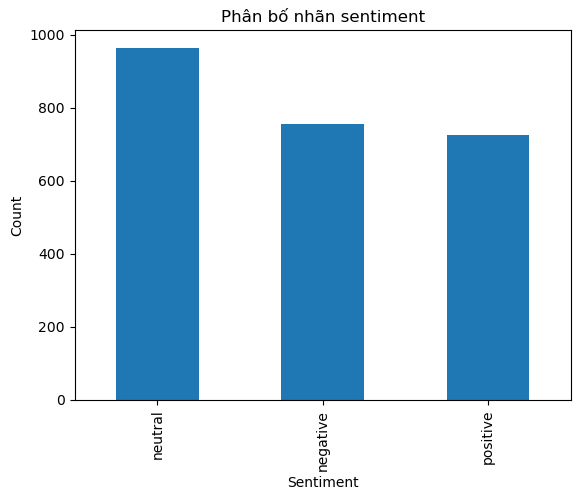

In [11]:
import matplotlib.pyplot as plt

label_counts.plot(kind="bar")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Phân bố nhãn sentiment")
plt.show()

# Độ dài review (char/word)

In [12]:
df["len_char"] = df["review"].str.len()
df["len_word"] = df["review"].str.split().str.len()

In [13]:
df[["len_char", "len_word"]].describe()


,len_char,len_word
count,2444.000000,2444.000000
mean,238.051964,52.999182
std,42.524493,9.775248
min,116.000000,24.000000
25%,207.000000,46.000000
50%,235.000000,52.000000
75%,269.000000,60.000000
max,345.000000,80.000000


# EDA từ vựng (lexical)

## Tiền xử lý đơn giản cho EDA

In [15]:
import re

def clean_review(text):
    # Nếu không phải string thì trả về chuỗi rỗng
    if not isinstance(text, str):
        return ""
    
    # 1) Viết thường hết
    text = text.lower()
    
    # 2) Bỏ tất cả số
    text = re.sub(r"\d+", " ", text)
    
    # 3) Bỏ các ký hiệu, dấu câu (chỉ giữ lại chữ + khoảng trắng)
    # [^\w\s] = mọi thứ KHÔNG phải chữ/các ký tự "word" hoặc khoảng trắng
    # flags=re.UNICODE để hỗ trợ chữ có dấu tiếng Việt
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    
    # 3b) Bỏ riêng dấu gạch dưới "_" nếu còn
    text = text.replace("_", " ")
    
    # 4) Thu gọn khoảng trắng thừa
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


In [16]:
df["review_clean"] = df["review"].apply(clean_review)

In ra một vài mẫu kiểm tra sau xử lý đơn giản

In [17]:
df[["review", "review_clean", "sentiment"]].sample(10, random_state=0)


,review,review_clean,sentiment
1114,"Tổng Bí thư dự gặp mặt đại biểu Bộ Quốc phòng,...",tổng bí thư dự gặp mặt đại biểu bộ quốc phòng ...,positive
1323,Bốn lý do TPHCM làm đầu tàu trong chiến lược x...,bốn lý do tphcm làm đầu tàu trong chiến lược x...,positive
2295,"Đang quay MV, nữ ca sĩ đột ngột ngất xỉu phải ...",đang quay mv nữ ca sĩ đột ngột ngất xỉu phải n...,negative
536,Lamine Yamal phá vỡ im lặng đua Quả bóng vàng ...,lamine yamal phá vỡ im lặng đua quả bóng vàng ...,neutral
1190,Ông Zelensky quyết không nhượng đất lấy hòa bì...,ông zelensky quyết không nhượng đất lấy hòa bì...,negative
986,Giá vàng hôm nay 19/7/2025: Vàng miếng SJC chố...,giá vàng hôm nay vàng miếng sjc chốt tuần tăng...,neutral
2426,"Nga ra tối hậu thư, ông Trump muốn ông Putin t...",nga ra tối hậu thư ông trump muốn ông putin th...,negative
1284,Bộ trưởng Công an: Chính các bạn trẻ phải bảo ...,bộ trưởng công an chính các bạn trẻ phải bảo v...,positive
2137,Chi tiết bộ máy Quốc hội và nhân sự Ủy ban Thư...,chi tiết bộ máy quốc hội và nhân sự ủy ban thư...,neutral
2015,4 huyền thoại Man United khiến fan Việt vỡ oà ...,huyền thoại man united khiến fan việt vỡ oà cả...,positive


## Đếm từ phổ biến toàn corpus

In [18]:
from collections import Counter

all_words = " ".join(df["review_clean"]).split()
word_counts = Counter(all_words)
word_counts.most_common(50)

[('và', 1189),
 ('của', 1083),
 ('công', 975),
 ('trong', 914),
 ('người', 893),
 ('có', 810),
 ('ở', 753),
 ('với', 708),
 ('cho', 651),
 ('không', 637),
 ('đã', 624),
 ('các', 623),
 ('nam', 619),
 ('một', 597),
 ('được', 596),
 ('đồng', 593),
 ('bị', 571),
 ('quốc', 568),
 ('tại', 554),
 ('khi', 524),
 ('về', 523),
 ('bộ', 523),
 ('là', 497),
 ('việt', 494),
 ('xe', 487),
 ('năm', 486),
 ('để', 443),
 ('chính', 425),
 ('nhà', 422),
 ('vào', 420),
 ('nhân', 418),
 ('sau', 416),
 ('từ', 408),
 ('hàng', 407),
 ('đầu', 397),
 ('trung', 395),
 ('động', 389),
 ('học', 385),
 ('trên', 381),
 ('nước', 379),
 ('định', 377),
 ('nội', 377),
 ('thành', 374),
 ('ra', 371),
 ('cấp', 367),
 ('nhiều', 366),
 ('hà', 365),
 ('an', 352),
 ('làm', 345),
 ('hành', 343)]

## Đếm từ theo từng nhãn

In [20]:
def top_words_for_label(label, n=30):
    subset = df[df["sentiment"] == label]
    words = " ".join(subset["review_clean"]).split()
    return Counter(words).most_common(n)

top_pos = top_words_for_label("positive", 30)
top_neu = top_words_for_label("neutral", 30)
top_neg = top_words_for_label("negative", 30)

print("Số từ theo nhãn positive", top_pos)
print("Số từ theo nhãn neutral", top_neu)
print("Số từ theo nhãn negative", top_neg)

Số từ theo nhãn positive [('và', 436), ('của', 349), ('công', 294), ('nam', 275), ('trong', 270), ('việt', 268), ('với', 240), ('cho', 225), ('người', 224), ('được', 217), ('có', 214), ('là', 213), ('quốc', 199), ('tại', 190), ('các', 184), ('một', 175), ('năm', 174), ('đồng', 165), ('ở', 161), ('học', 160), ('thành', 159), ('đầu', 159), ('không', 158), ('đã', 152), ('mới', 147), ('về', 146), ('động', 145), ('để', 137), ('nhà', 133), ('nhân', 128)]
Số từ theo nhãn neutral [('và', 492), ('của', 403), ('có', 402), ('công', 373), ('trong', 361), ('bộ', 330), ('với', 307), ('các', 292), ('cho', 263), ('về', 257), ('không', 256), ('năm', 247), ('được', 246), ('đồng', 244), ('chính', 243), ('giá', 235), ('người', 233), ('ở', 227), ('quốc', 226), ('nam', 203), ('tại', 201), ('định', 200), ('là', 198), ('khi', 191), ('việt', 187), ('nay', 184), ('cấp', 183), ('một', 181), ('đã', 178), ('trung', 172)]
Số từ theo nhãn negative [('người', 436), ('bị', 417), ('ở', 365), ('của', 331), ('công', 308)

## Trực quan hoá cho dễ nhìn

In [21]:
import pandas as pd
from collections import Counter

# df đã load và có cột review_clean
# df["review_clean"] = df["review"].apply(clean_review)  # đã làm ở bước trước

# Tách tất cả từ trong toàn corpus
all_words = " ".join(df["review_clean"]).split()
word_counts = Counter(all_words)

# Lấy top 30 từ phổ biến nhất
top_n = 30
top_words_all = word_counts.most_common(top_n)
top_words_all[:10]

[('và', 1189),
 ('của', 1083),
 ('công', 975),
 ('trong', 914),
 ('người', 893),
 ('có', 810),
 ('ở', 753),
 ('với', 708),
 ('cho', 651),
 ('không', 637)]

In [22]:
def top_words_for_label(label, n=30):
    subset = df[df["sentiment"] == label]
    words = " ".join(subset["review_clean"]).split()
    return Counter(words).most_common(n)

labels = df["sentiment"].unique().tolist()  # ví dụ: ["positive", "neutral", "negative"]

top_words_by_label = {
    label: top_words_for_label(label, top_n)
    for label in labels
}


Hàm vẽ bar chart đẹp

In [24]:
import matplotlib.pyplot as plt
import numpy as np

def plot_top_words(top_words, title, color=None, figsize=(10, 6)):
    """
    top_words: list of (word, count)
    title: tiêu đề
    color: màu cho cột (chuỗi hoặc list), nếu None sẽ dùng màu mặc định
    """
    words = [w for w, c in top_words]
    counts = [c for w, c in top_words]

    # Đảo ngược để vẽ barh từ dưới lên trên (top ở trên cùng)
    words = words[::-1]
    counts = counts[::-1]

    plt.figure(figsize=figsize)

    y_pos = np.arange(len(words))

    if color is None:
        plt.barh(y_pos, counts)
    else:
        plt.barh(y_pos, counts, color=color)

    plt.yticks(y_pos, words, fontsize=10)
    plt.xlabel("Tần suất", fontsize=12)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


Trực quan hóa top từ phổ biến toàn bộ dữ liệu

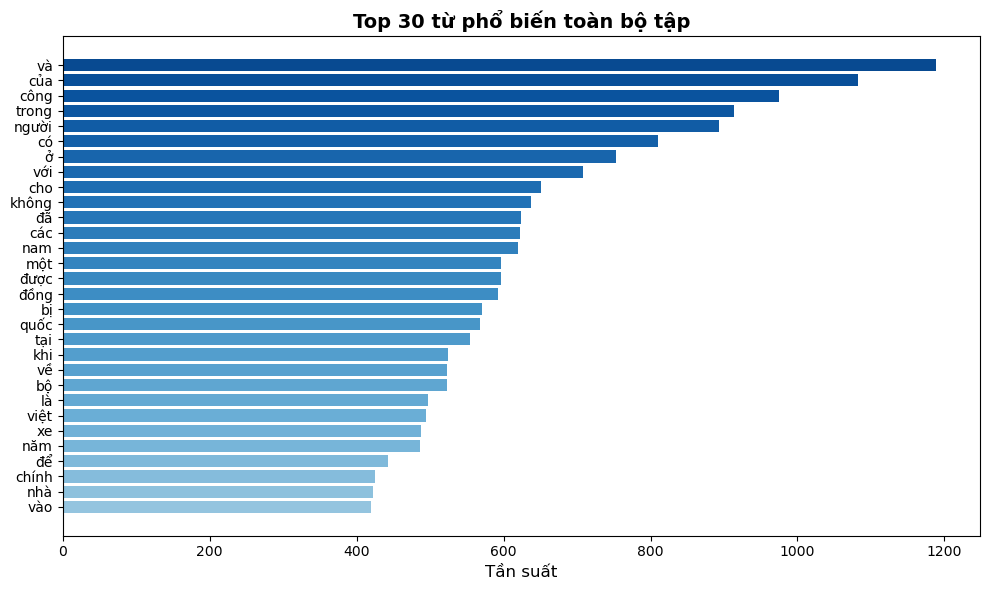

In [25]:
# Tạo màu gradient cho top N từ
from matplotlib import cm

colors_all = cm.Blues(np.linspace(0.4, 0.9, top_n))  # xanh dương nhạt → đậm

plot_top_words(
    top_words_all,
    title=f"Top {top_n} từ phổ biến toàn bộ tập",
    color=colors_all
)


Trực quan hóa top từ theo từng nhãn sentiment

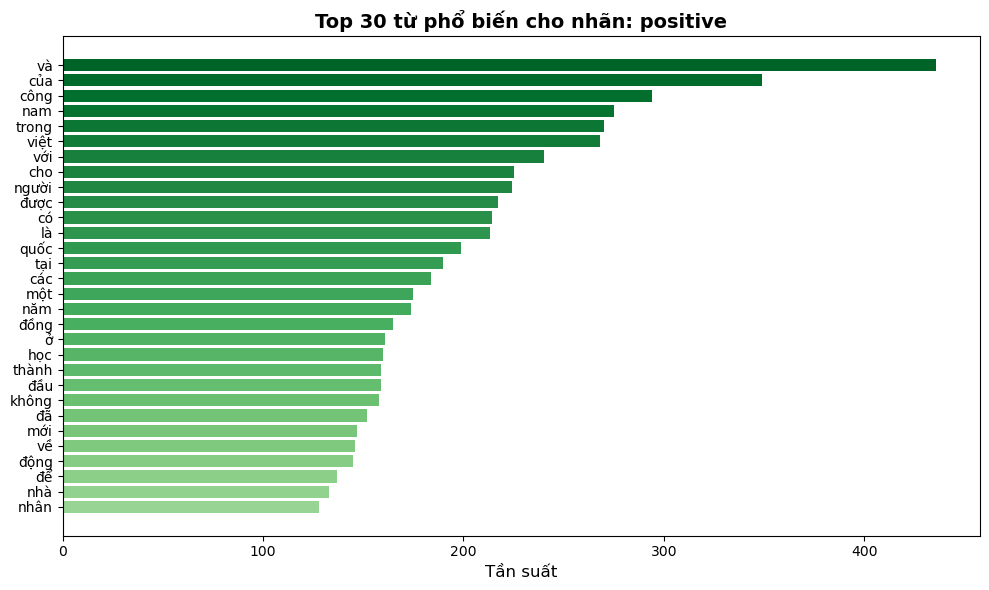

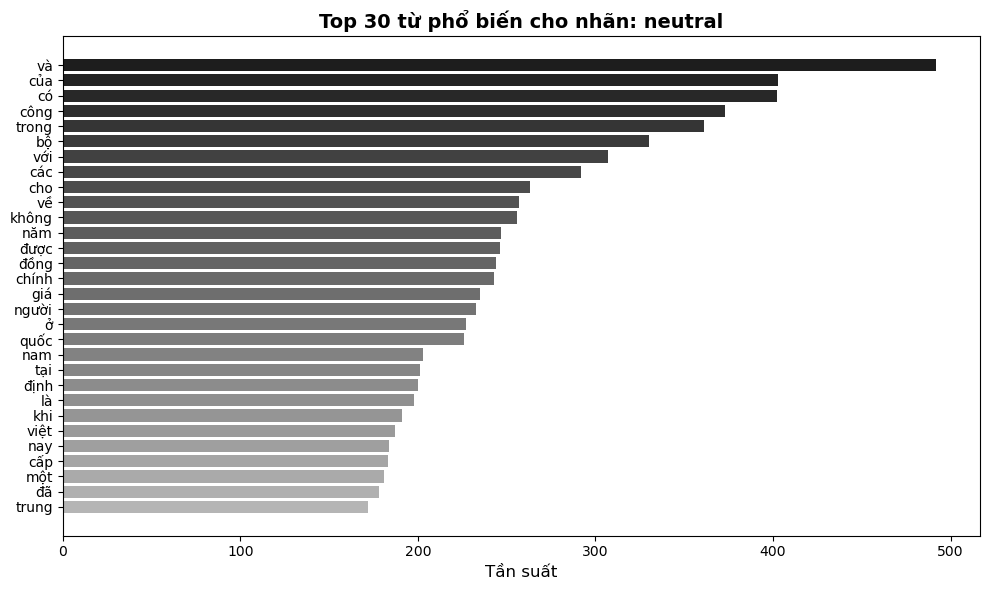

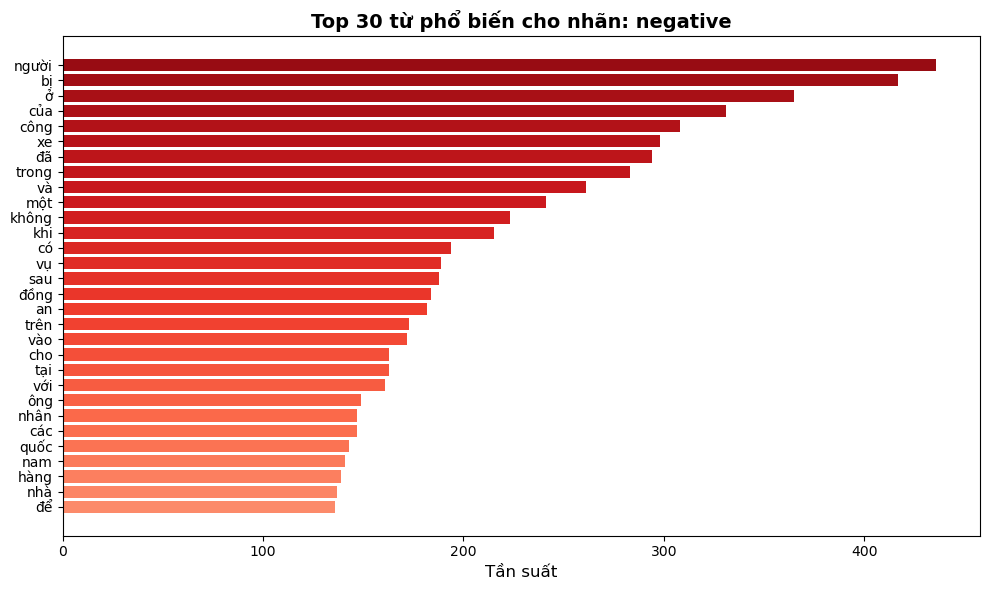

In [26]:
from matplotlib import cm

# Map nhãn → colormap
label_cmaps = {
    "positive": cm.Greens,
    "neutral": cm.Greys,
    "negative": cm.Reds
}

for label in labels:
    top_words = top_words_by_label[label]
    cmap = label_cmaps.get(label, cm.Blues)  # fallback nếu nhãn lạ
    colors = cmap(np.linspace(0.4, 0.9, len(top_words)))  # gradient

    plot_top_words(
        top_words,
        title=f"Top {len(top_words)} từ phổ biến cho nhãn: {label}",
        color=colors
    )


# WORDCLOUD

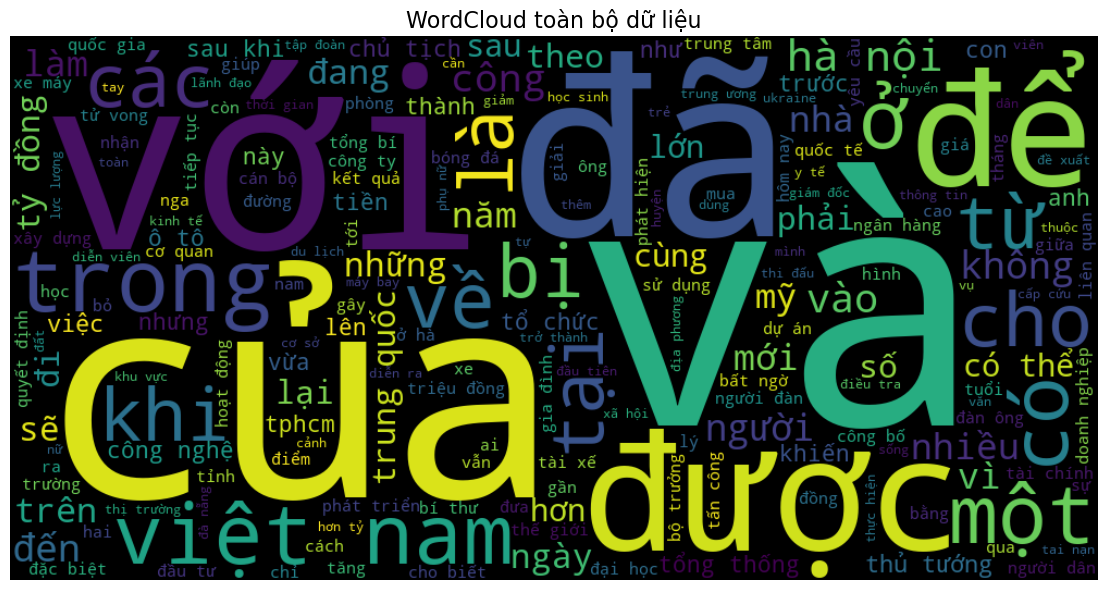

In [28]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ghép tất cả review_clean thành một chuỗi dài
text_all = " ".join(df["review_clean"].tolist())

# Tạo wordcloud (dùng màu mặc định)
wc_all = WordCloud(
    width=1000,
    height=500
).generate(text_all)

plt.figure(figsize=(12, 6))
plt.imshow(wc_all, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud toàn bộ dữ liệu", fontsize=16)
plt.tight_layout()
plt.show()

# Tách tập train và tập test, lưu xuống file

## Cell 1: Import thư viện và Load dữ liệu thô

In [9]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from pyvi import ViTokenizer

# Load dữ liệu
# Sử dụng try-except để xử lý cả 2 trường hợp JSON array hoặc JSON lines
file_path = 'final-round.json'
try:
    df = pd.read_json(file_path)
except ValueError:
    df = pd.read_json(file_path, lines=True)

print(f"Tổng số mẫu dữ liệu ban đầu: {len(df)}")
df.head()

Tổng số mẫu dữ liệu ban đầu: 2444


,review,sentiment
0,Từ học bổng thay đổi cuộc đời đến lớp học tiến...,positive
1,Trường ĐH Tôn Đức Thắng công bố 4 nhóm nghiên ...,positive
2,Đề thi thử tốt nghiệp THPT môn Toán của thành ...,neutral
3,Sở Giáo dục TPHCM lên tiếng việc 47.000 giáo v...,neutral
4,Người mẹ trăn trở trước giờ ghi 'đơn xanh' ngu...,negative


## Cell 2: Chia tập dữ liệu (Splitting)

In [10]:
# Xác định Feature và Label
X = df['review'] # Chỉ lấy cột text thô
y = df['sentiment']

# BƯỚC 1: Tách Train (70%) và Phần còn lại (30%)
# train_size = 0.7
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    train_size=0.7, 
    random_state=42, 
    stratify=y
)

# BƯỚC 2: Tách Phần còn lại (30%) thành Dev (10% tổng) và Test (20% tổng)
# Để có Test chiếm 20% tổng thể từ tập Temp (30% tổng thể), ta cần lấy tỉ lệ 2/3 (0.66...)
X_dev, X_test, y_dev, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=2/3, 
    random_state=42, 
    stratify=y_temp
)

# Đóng gói lại thành DataFrame để tiện xử lý
df_train = pd.DataFrame({'review': X_train, 'sentiment': y_train})
df_dev = pd.DataFrame({'review': X_dev, 'sentiment': y_dev})
df_test = pd.DataFrame({'review': X_test, 'sentiment': y_test})

# Kiểm tra kích thước
total_len = len(df)
print(f"Train: {len(df_train)} mẫu ({len(df_train)/total_len:.1%})")
print(f"Dev:   {len(df_dev)} mẫu ({len(df_dev)/total_len:.1%})")
print(f"Test:  {len(df_test)} mẫu ({len(df_test)/total_len:.1%})")

Train: 1710 mẫu (70.0%)
Dev:   244 mẫu (10.0%)
Test:  490 mẫu (20.0%)


# Preprocessing dữ liệu

## Load danh sách Stopwords

In [11]:
# Load stopwords
stopword_file = 'vietnamese-stopwords.txt'

try:
    with open(stopword_file, 'r', encoding='utf-8') as f:
        content = f.read().splitlines()
    
    # Chuẩn hóa stopword cho pyvi (thay khoảng trắng bằng gạch dưới)
    # Ví dụ: "sinh viên" -> "sinh_viên"
    stopwords_set = set([word.strip().replace(' ', '_') for word in content])
    print(f"Đã load {len(stopwords_set)} stopwords.")

except FileNotFoundError:
    print("Lỗi: Không tìm thấy file stopwords. Danh sách rỗng.")
    stopwords_set = set()

Đã load 1942 stopwords.


## Định nghĩa hàm Preprocessing

In [12]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Chuyển thành chữ thường
    text = text.lower()
    
    # 2. Loại bỏ URLs, Hashtags, Mentions
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[#@]\S+', ' ', text)
    
    # 3. [MỚI] Loại bỏ Số và Dấu câu
    # - Xóa tất cả các số
    text = re.sub(r'\d+', ' ', text)
    
    # - Xóa tất cả các ký tự KHÔNG phải là chữ cái (word char) hoặc khoảng trắng
    #   Lưu ý: Trong Python, \w đã bao gồm cả các chữ cái tiếng Việt có dấu.
    #   Regex này sẽ loại bỏ: ., -, ?, !, ", ', v.v.
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # 4. Tách từ (Word Segmentation) bằng pyvi
    # Kết quả: "tôi là sinh_viên"
    tokenized_text = ViTokenizer.tokenize(text)
    
    # 5. Loại bỏ Stopwords
    # (Đảm bảo bạn đã chạy Cell 3 để có biến stopwords_set)
    tokens = tokenized_text.split()
    filtered_tokens = [word for word in tokens if word not in stopwords_set]
    
    # 6. Ghép lại và xóa khoảng trắng thừa
    # Việc replace ở trên có thể tạo ra nhiều khoảng trắng thừa, ta dùng join để chuẩn hóa lại
    return " ".join(filtered_tokens)

# Test thử hàm mới
sample = "Hôm nay ngày 20-11, tôi đi học... vui quá! @student #hcm 100 điểm."
print("Gốc: ", sample)
print("Sạch: ", preprocess_text(sample))
# Kỳ vọng: hôm_nay đi học vui quá điểm (mất số 20, 11, 100 và các dấu)

Gốc:  Hôm nay ngày 20-11, tôi đi học... vui quá! @student #hcm 100 điểm.
Sạch:  hôm_nay đi học vui


## Áp dụng Preprocessing cho từng tập (Train, Dev, Test)

In [13]:
# 1. Áp dụng Preprocessing
print("Đang xử lý tập Train...")
df_train['review_preprocessed'] = df_train['review'].apply(preprocess_text)

print("Đang xử lý tập Dev...")
df_dev['review_preprocessed'] = df_dev['review'].apply(preprocess_text)

print("Đang xử lý tập Test...")
df_test['review_preprocessed'] = df_test['review'].apply(preprocess_text)

# 2. Loại bỏ dòng rỗng (nếu sau khi xử lý review bị rỗng)
df_train = df_train[df_train['review_preprocessed'].str.strip() != '']
df_dev = df_dev[df_dev['review_preprocessed'].str.strip() != '']
df_test = df_test[df_test['review_preprocessed'].str.strip() != '']

# 3. CHỈ GIỮ LẠI 2 CỘT: review (đã xử lý) và sentiment
# - Lấy cột 'review_preprocessed' và 'sentiment'
# - Đổi tên 'review_preprocessed' trở lại thành 'review' cho gọn
def finalize_columns(df):
    df_final = df[['review_preprocessed', 'sentiment']].copy()
    df_final.rename(columns={'review_preprocessed': 'review'}, inplace=True)
    return df_final

df_train = finalize_columns(df_train)
df_dev = finalize_columns(df_dev)
df_test = finalize_columns(df_test)

print("Hoàn tất! Cấu trúc dữ liệu hiện tại:")
print("Train columns:", df_train.columns.tolist())
print(f"Số lượng mẫu Train: {len(df_train)}")
print("-" * 30)
print(df_train.head())

Đang xử lý tập Train...
Đang xử lý tập Dev...
Đang xử lý tập Test...
Hoàn tất! Cấu trúc dữ liệu hiện tại:
Train columns: ['review', 'sentiment']
Số lượng mẫu Train: 1710
------------------------------
                                                 review sentiment
1514  khởi_tố bị_can vụ sập hội_trường thị_trấn cơ_q...  negative
831   lãi_suất ngân_hàng hôm_nay băng điều_chỉnh lãi...   neutral
984   vinachem kiên_định mục_tiêu tăng_trưởng phường...  positive
1357  vụ cuộn vải bạt rơi ô_tô đè chết nam bảo_vệ kh...  negative
2438  cđv bình dương đội nắng săn vé tuyển việt nam_...   neutral


In [14]:
print("Đang lưu file JSON...")

# Lưu dữ liệu (đã gồm bước chọn cột ở trên)
df_train.to_json('train_processed.json', orient='records', lines=True, force_ascii=False)
df_dev.to_json('dev_processed.json', orient='records', lines=True, force_ascii=False)
df_test.to_json('test_processed.json', orient='records', lines=True, force_ascii=False)

print("Đã cập nhật xong 3 file: train_processed.json, dev_processed.json, test_processed.json")

# Kiểm tra lại nội dung file vừa lưu
print("\nCheck nội dung file train_processed.json:")
with open('train_processed.json', 'r', encoding='utf-8') as f:
    print(f.readline().strip())  # In dòng đầu tiên

Đang lưu file JSON...
Đã cập nhật xong 3 file: train_processed.json, dev_processed.json, test_processed.json

Check nội dung file train_processed.json:
{"review":"khởi_tố bị_can vụ sập hội_trường thị_trấn cơ_quan cảnh_sát điều_tra công_an tp thơ khởi_tố bị_can vụ sập hội_trường chỗ ubnd thị_trấn tỉnh hậu giang cũ xảy","sentiment":"negative"}
